This project focuses on multi-label domestic sound classification using engineered acoustic features extracted from audio recordings.
The dataset consists of mel spectrogram statistics, MFCC-based descriptors and spectral features computed over short overlapping segments of audio recordings. Each segment contains annotations from multiple annotators.

In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import os
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, average_precision_score, make_scorer, multilabel_confusion_matrix
from sklearn.model_selection import GroupKFold, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

In [2]:
features_datapath = "audio_features/"
metadata = pd.read_csv("metadata.csv")

# Dataset construction

The dataset consists of acoustic features extracted from audio file recordings and corresponding annotations from different human annotators.

Each file consists of:
- aggregated acoustic features for short time segments
- time-aligned annotations from multiple annotators
- metadata

To prepare the dataset for classification problem only mean and standard deviation of acoustic features were selected(min and max were not), because of the computational demand. Additionally, these 2 feature properties should be enough to explain most of the correlations.

All features were concatenated into a single feature vector, annotators from different annotators were aggregated using threshold of 0.5. The resulting dataset contains one sample per audio segment.

In [3]:
X_list = []
y_list = []
file_ids = []
collectors = []

for file in os.listdir(features_datapath):
    file_path = os.path.join(features_datapath, file)
    data = dict(np.load(file_path, allow_pickle=True))

    features = []
    for key in data.keys():
            if key.endswith("_mean") or key.endswith("_std"):
                features.append(data[key])

    X = np.concatenate(features, axis=1)

    annotations = data["annotations"]  

    agg = annotations.mean(axis=2)

    y = (agg >= 0.5).astype(int)

    X_list.append(X)
    y_list.append(y)
    filename = file.replace(".npz", "")
    file_ids.extend([filename] * X.shape[0])

X = np.vstack(X_list)
y = np.vstack(y_list)
file_ids = np.array(file_ids)
X

array([[0.10880859, 0.07402539, 5.21278   , ..., 0.88905925, 0.12102454,
        0.07108451],
       [0.09867188, 0.06503905, 5.52330494, ..., 0.76841575, 0.14803316,
        0.06644332],
       [0.08880859, 0.0442627 , 5.65089369, ..., 0.52718621, 0.14215684,
        0.05696157],
       ...,
       [0.10884766, 0.01914233, 6.00029659, ..., 0.78609014, 0.38550189,
        0.25794289],
       [0.14111328, 0.03966563, 5.82893944, ..., 4.1692543 , 4.99350023,
        8.86816025],
       [0.17111328, 0.0387998 , 5.86982155, ..., 5.58871222, 8.10689068,
        9.41787624]], shape=(168239, 480))

## Train-test Split

To evaluate the classification performance reliably, the dataset was divided into separate training and test sets.

### Information Leakage

The dataset contains multiple overlapping time segments. Randomly splitting individual segments could result in segments from the same recording appearing both in train and test set, leading to informational leakage and overly-optimistic results.

To deal with that the split was performed on recording level using unique file ids. Because of this, all the segments from a single recording were assigned to the same split.

In [4]:
unique_files = np.unique(file_ids)

train_files, test_files = train_test_split(unique_files, test_size=0.2, random_state=42)

def get_mask(files):
        return np.isin(file_ids, files)

train_mask = get_mask(train_files)
test_mask  = get_mask(test_files)

X_train, X_test = X[train_mask],X[test_mask]
y_train, y_test = y[train_mask],y[test_mask]
file_ids_train = file_ids[train_mask]
file_ids_test = file_ids[test_mask]
print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (134980, 480)
Test: (33259, 480)


## Class distribution Analysis

After creating train-test splits, the class distributions were analyzed to ensure class balance among both splits.



In [5]:
def get_class_distribution(y):
    counts = y.sum(axis=0)
    proportions = counts / y.shape[0]
    return counts, proportions

train_counts, train_props = get_class_distribution(y_train)
test_counts, test_props = get_class_distribution(y_test)

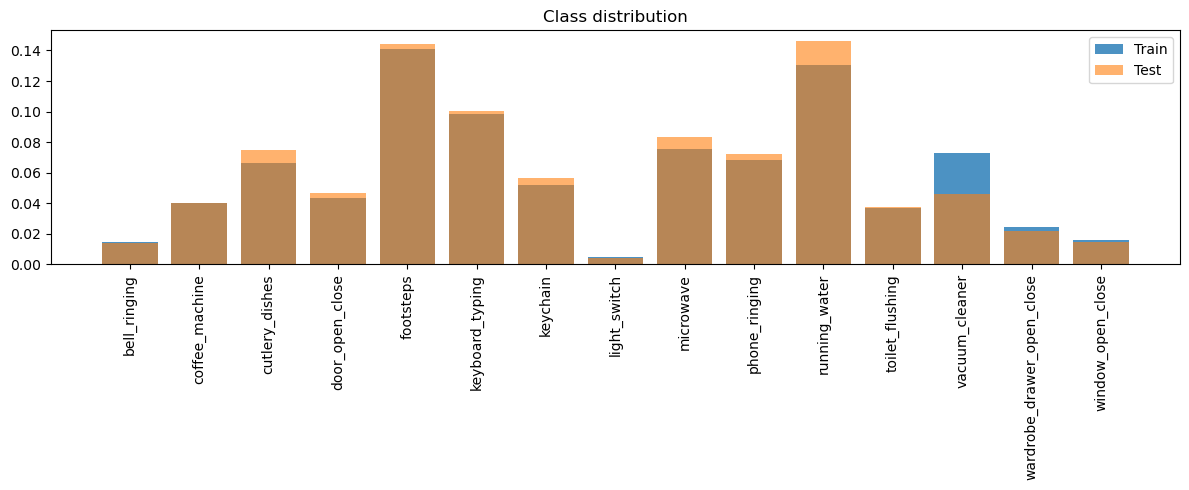

In [ ]:
class_names = data["class_names"]

plt.figure(figsize=(12, 5))
plt.bar(class_names, train_props, alpha=0.8, label="Train")
plt.bar(class_names, test_props, alpha=0.6, label="Test")
plt.xticks(rotation=90)
plt.legend()
plt.title("Class distribution")
plt.tight_layout()
plt.savefig('class_distrib.png')
plt.show()

As we can see all the classes are consistent among both train and test splits.

## Standardization

Many machine learning algorithms we have tested are sensitive to the scale of input features. Since the acoustic features have different numerical ranges, standardization of the data was applied.

In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Baseline performance

Before training complex machine learning algorithms a simple baseline performance was established. For each sound event class the empirical probability of occurrences on training data were computed, predictions then were computed according to those probabilities.

### Evaluation Metrics

Two metrics were used: Macro F1 and Mean average Precision(mAP). The first one evaluates performance equally across all classes, and the second one measures ranking quality.

In [8]:
p = y_train.mean(axis=0)
y_scores = np.tile(p, (y_test.shape[0], 1))
y_pred = (np.random.rand(*y_test.shape) < y_scores).astype(int)
f1 = f1_score(y_test, y_pred, average="macro")
map_score = average_precision_score(y_test, y_scores, average="macro")
print("F1 (macro):", f1)
print("mAP:", map_score)

F1 (macro): 0.05813415940070258
mAP: 0.060170179500285643


## Model Selection and Hyperparameter search

To identify the most suitable classifier for our task, several machine learning algorithms, such as LogisticRegression, NaiveBayes, KNN, RandomForest, SVM, XGBoost, LightGBM, CatBoost, MultiLayerPerceptron, were evaluated.

For each classifier, hyperparameter searches were performed using GridSearchCV with 5-fold grouped cross-validation preventing information leakage.

The training was done on 10-th part of the data for time complexity demands, but the best models were then retrained using full data with best hyperparameters.

In [9]:
f1_macro = make_scorer(f1_score, average="macro")

gkf = GroupKFold(n_splits=5)

lr_pg = {'estimator__C': [5, 10, 20],'estimator__l1_ratio': [0],'estimator__solver': ['saga']}
nb_pg ={'estimator__var_smoothing': np.logspace(-12, -6, 50)}
knn_pg = {'estimator__n_neighbors': [5, 10, 30, 50], 'estimator__weights': ["uniform", "distance"], 'estimator__p': [1, 2]} 
rf_pg = {'n_estimators': [100, 200],'max_depth': [10, None],'min_samples_split': [2, 5],'min_samples_leaf': [1, 2],'max_features': ["sqrt"]}
svm_pg = {'estimator__C': [1, 10],'estimator__kernel': ["linear", "rbf"],'estimator__gamma': ["auto"]}
xgb_pg = {'n_estimators': [100, 200],'max_depth': [3,6],'learning_rate': [0.1, 0.05],'subsample': [0.8, 1.0],'colsample_bytree': [0.8, 1.0]}
lgbm_pg = {'estimator__n_estimators': [100, 200],'estimator__num_leaves': [31, 63],'estimator__learning_rate': [0.05, 0.1],'estimator__max_depth"': [-1, 10],'estimator__subsample': [1.0]}
cat_pg = {'iterations': [200, 400],'depth': [4, 6],'learning_rate': [0.05, 0.1],'l2_leaf_reg': [1, 3, 5]}
mlp_pg = {'hidden_layer_sizes': [(512, 512),(512, 256),(256, 128),(256, 256)],'alpha': [1e-2],'learning_rate_init': [1e-3],'activation': ["relu"]}

In [ ]:
search_lr = GridSearchCV(OneVsRestClassifier(LogisticRegression(max_iter=300, random_state=42)), param_grid=lr_pg, cv=gkf, n_jobs=-1, scoring=f1_macro)
search_nb = GridSearchCV(OneVsRestClassifier(GaussianNB()), param_grid=nb_pg, cv=gkf,n_jobs=-1, scoring=f1_macro)
search_knn = GridSearchCV(OneVsRestClassifier(KNeighborsClassifier()), param_grid=knn_pg, cv=gkf,n_jobs=-1, scoring=f1_macro)
search_svm = GridSearchCV(OneVsRestClassifier(SVC(probability=True, random_state=42)), param_grid=svm_pg, cv=gkf,n_jobs=-1, scoring=f1_macro)
search_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid=rf_pg, cv=gkf, n_jobs=-1, scoring=f1_macro)
search_xgb = GridSearchCV(XGBClassifier(random_state=42, eval_metric="logloss"), param_grid=xgb_pg, cv=gkf, n_jobs=-1, scoring=f1_macro)
search_lgbm = GridSearchCV(OneVsRestClassifier(LGBMClassifier(random_state=42)), param_grid=lgbm_pg, cv=gkf, n_jobs=-1, scoring=f1_macro)
search_cat = GridSearchCV(CatBoostClassifier(loss_function="MultiLogloss", random_state=42), param_grid=cat_pg, cv=gkf, n_jobs=-1, scoring=f1_macro)
search_mlp = GridSearchCV(MLPClassifier(max_iter=300, random_state=42), param_grid=mlp_pg, cv=gkf, n_jobs=-1, scoring=f1_macro)

In [13]:
search_lr.fit(X_train[:10000], y_train[:10000], groups=file_ids_train[:10000])
print(f'LogisticRegression best score is {search_lr.best_score_} with parameters: {search_lr.best_params_}')

c:\Users\vlads\anaconda3\envs\lfugd\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\vlads\anaconda3\envs\lfugd\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\vlads\anaconda3\envs\lfugd\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\vlads\anaconda3\envs\lfugd\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\vlads\anaconda3\envs\lfugd\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\vlads\anaconda3\envs\lfugd\Lib\site-packages\s

LogisticRegression best score is 0.3735387612575701 with parameters: {'estimator__C': 10, 'estimator__l1_ratio': 0, 'estimator__solver': 'saga'}


c:\Users\vlads\anaconda3\envs\lfugd\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [49]:
search_nb.fit(X_train[:10000], y_train[:10000], groups=file_ids_train[:10000])
print(f'NaiveByes best score is {search_nb.best_score_} with parameters: {search_nb.best_params_}')

NaiveByes best score is 0.23053750810979565 with parameters: {'estimator__var_smoothing': np.float64(1e-12)}


In [50]:
search_knn.fit(X_train[:10000], y_train[:10000], groups=file_ids_train[:10000])
print(f'KNN best score is {search_knn.best_score_} with parameters: {search_knn.best_params_}')

KNN best score is 0.2931412269059483 with parameters: {'estimator__n_neighbors': 5, 'estimator__p': 2, 'estimator__weights': 'distance'}


In [51]:
search_xgb.fit(X_train[:10000], y_train[:10000], groups=file_ids_train[:10000])
print(f'XGB best score is {search_xgb.best_score_} with parameters: {search_xgb.best_params_}')

XGB best score is 0.3560110428838865 with parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}


In [9]:
search_lgbm.fit(X_train[:10000], y_train[:10000], groups=file_ids_train[:10000])
print(f'LGBM best score is {search_lgbm.best_score_} with parameters: {search_lgbm.best_params_}')

[LightGBM] [Warning] max_depth is set=-1, max_depth=-1 will be ignored. Current value: max_depth=-1
[LightGBM] [Warning] max_depth is set=-1, max_depth=-1 will be ignored. Current value: max_depth=-1
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.028112 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 122400
[LightGBM] [Info] Number of data points in the train set: 10000, number of used features: 480
[LightGBM] [Info] Start training from score 0.016900
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] max_depth is set=-1, max_depth=-1 will be ignored. Current value: max_depth=-1
[LightGBM] [Warning] max_depth is set=-1, max_depth=-1 will be ignored. Current value: max_depth=-1
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.040780 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] 

In [52]:
search_rf.fit(X_train[:10000], y_train[:10000], groups=file_ids_train[:10000])
print(f'RF best score is {search_rf.best_score_} with parameters: {search_rf.best_params_}')

RF best score is 0.19829944326450838 with parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


In [14]:
search_svm.fit(X_train[:10000], y_train[:10000], groups=file_ids_train[:10000])
print(f'SVM best score is {search_svm.best_score_} with parameters: {search_svm.best_params_}')

SVM best score is 0.38753275600928455 with parameters: {'estimator__C': 10, 'estimator__gamma': 'auto', 'estimator__kernel': 'rbf'}


In [15]:
search_mlp.fit(X_train[:10000], y_train[:10000], groups=file_ids_train[:10000])
print(f'MLP best score is {search_mlp.best_score_} with parameters: {search_mlp.best_params_}')

MLP best score is 0.4209566980603909 with parameters: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (256, 256), 'learning_rate_init': 0.001}


In [10]:
search_cat.fit(X_train[:10000], y_train[:10000], groups=file_ids_train[:10000])
print(f'CAtBoost best score is {search_cat.best_score_} with parameters: {search_cat.best_params_}')

0:	learn: 0.5388967	total: 296ms	remaining: 1m 58s
1:	learn: 0.4337238	total: 433ms	remaining: 1m 26s
2:	learn: 0.3603532	total: 562ms	remaining: 1m 14s
3:	learn: 0.3077197	total: 690ms	remaining: 1m 8s
4:	learn: 0.2664861	total: 822ms	remaining: 1m 4s
5:	learn: 0.2386812	total: 962ms	remaining: 1m 3s
6:	learn: 0.2172742	total: 1.09s	remaining: 1m 1s
7:	learn: 0.2030020	total: 1.21s	remaining: 59.3s
8:	learn: 0.1896469	total: 1.34s	remaining: 58.3s
9:	learn: 0.1806343	total: 1.46s	remaining: 57.1s
10:	learn: 0.1729679	total: 1.59s	remaining: 56.3s
11:	learn: 0.1669076	total: 1.72s	remaining: 55.5s
12:	learn: 0.1620884	total: 1.84s	remaining: 54.7s
13:	learn: 0.1576679	total: 1.96s	remaining: 54.1s
14:	learn: 0.1543568	total: 2.08s	remaining: 53.4s
15:	learn: 0.1504206	total: 2.2s	remaining: 52.8s
16:	learn: 0.1473742	total: 2.32s	remaining: 52.3s
17:	learn: 0.1445749	total: 2.44s	remaining: 51.8s
18:	learn: 0.1425568	total: 2.55s	remaining: 51.2s
19:	learn: 0.1400898	total: 2.68s	remai

After hyperparameter tuning we observe that the best models were LogisticRegression, MLP, and XGBoost. Only those algorithms are further retrained on full data.

## Final Model Evaluation

After completing hyperparameter tuning the best-performing configurations were used to retrain best classifiers on the full data.

In [16]:
mlp_model = MLPClassifier(max_iter=500, random_state=42, activation='relu', alpha=0.01, hidden_layer_sizes=(256, 256), learning_rate_init=0.001, early_stopping=True, n_iter_no_change=15)
mlp_model.fit(X_train, y_train)
joblib.dump(mlp_model, "mlp_model.pkl")
y_pred_mlp = mlp_model.predict(X_test)
if hasattr(mlp_model, "predict_proba"):
    y_scores_mlp = mlp_model.predict_proba(X_test)
else:
    y_scores_mlp = y_pred_mlp

f1_mlp = f1_score(y_test, y_pred_mlp, average="macro")
mAP_mlp = average_precision_score(y_test, y_scores_mlp, average="macro")

print("Final F1 for MLP:", f1_mlp)
print("Final mAP for MLP:", mAP_mlp)

Final F1 for MLP: 0.51103989764406
Final mAP for MLP: 0.5385944699670449


In [17]:
xgb_model = XGBClassifier(random_state=42, eval_metric="logloss", colsample_bytree=0.8,  learning_rate=0.1, n_estimators=200, max_depth=3, subsample=1.0)
xgb_model.fit(X_train, y_train)
joblib.dump(xgb_model, "xgb_model.pkl")
y_pred_xgb = xgb_model.predict(X_test)
if hasattr(xgb_model, "predict_proba"):
    y_scores_xgb = xgb_model.predict_proba(X_test)
else:
    y_scores_xgb = y_pred_xgb

f1_xgb = f1_score(y_test, y_pred_xgb, average="macro")
mAP_xgb = average_precision_score(y_test, y_scores_xgb, average="macro")

print("Final F1 for xgb:", f1_xgb)
print("Final mAP for xgb:", mAP_xgb)

Final F1 for xgb: 0.45192178333238436
Final mAP for xgb: 0.5601059753095203


In [18]:
lr_model = OneVsRestClassifier(LogisticRegression(max_iter=500, random_state=42, l1_ratio=0, solver='saga', C=10))
lr_model.fit(X_train, y_train)
joblib.dump(lr_model, "lr_model.pkl")
y_pred_lr = lr_model.predict(X_test)
if hasattr(lr_model, "predict_proba"):
    y_scores_lr = lr_model.predict_proba(X_test)
else:
    y_scores_lr = y_pred_lr

f1_lr = f1_score(y_test, y_pred_lr, average="macro")
mAP_lr = average_precision_score(y_test, y_scores_lr, average="macro")

print("Final F1 for xgb:", f1_lr)
print("Final mAP for xgb:", mAP_lr)

c:\Users\vlads\anaconda3\envs\lfugd\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\vlads\anaconda3\envs\lfugd\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\vlads\anaconda3\envs\lfugd\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\vlads\anaconda3\envs\lfugd\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\vlads\anaconda3\envs\lfugd\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\vlads\anaconda3\envs\lfugd\Lib\site-packages\s

Final F1 for xgb: 0.44012665532769785
Final mAP for xgb: 0.509559809287952


## Final Model Comparison

The MLP achieved the highest Macro F1 score, indicating the strongest overall classification across all classes. This indicates that NN was able to learn some complex dependencies, which were missed by linear tree-based algorithms.

XGBoost achieved the highest mAP score, indicating more effectiveness in ranking relevant sound events over irrelevant ones.

Logistic Regression surprisingly provided slightly lower, but competitive results despite it's linear nature. This suggests that linear dependencies are also very important in our classification task.

Taking in consideration very complex nature of our multi-label sound event detection task, achieved results are very encouraging. They provide a strong foundation for future work with more advanced architectures.